In [7]:
# 📘 UTS Data Mining : Analisis Imbalanced Data
# Anggota Kelompok : - Muhammad Zahran Albara (122140240)
#                    - Casey Z.D Manurung (122140054)
#                    - Royfran Roger Valentino (122140239)
# Prodi: Teknik Informatika

# Tujuan:
# Menunjukkan proses lengkap analisis imbalanced data mulai dari eksplorasi, preprocessing, modeling, hingga penyeimbangan menggunakan SMOTE.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import entropy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

In [9]:

# 1️⃣ Baca seluruh file dan buang tanda kutip & baris kosong
with open("Dataset_UTS - Pembelian.csv", encoding="utf-8") as f:
    lines = [line.strip().replace('"', '') for line in f if line.strip()]

data = []
current_kode = None
current_produk = None
current_unit = None

# 2️⃣ Loop semua baris
for line in lines:
    # Lewati header
    if line.startswith("KODE") or line.startswith("TANGGAL"):
        continue

    # Deteksi baris kode produk (misal: A000001 ANATON TAB STRIP)
    match_kode = re.match(r'^(A\d+)\s+(.+?)\s+([A-Z]+)$', line)
    if match_kode:
        current_kode = match_kode.group(1)
        current_produk = match_kode.group(2).strip()
        current_unit = match_kode.group(3).strip()
        continue

    # Deteksi baris transaksi (misal: 06-07-21  1.13-210706.0908-003  10,00  2.520,00)
    match_trans = re.match(r'^\s*(\d{2}-\d{2}-\d{2})\s+([\w\.\-]+)\s+([\d,]+)\s+([\d\.,]+)', line)
    if match_trans and current_kode:
        tanggal = match_trans.group(1)
        no_trans = match_trans.group(2)
        qty = match_trans.group(3).replace(",", ".")
        nilai = match_trans.group(4).replace(".", "").replace(",", ".")
        data.append({
            "KODE": current_kode,
            "NAMA PRODUK": current_produk,
            "UNIT": current_unit,
            "TANGGAL": tanggal,
            "NO.TRANSAKSI": no_trans,
            "QTY.MSK": float(qty),
            "NILAI.MSK": float(nilai)
        })

# 3️⃣ Ubah ke DataFrame
df_pembelian = pd.DataFrame(data)

# 4️⃣ Simpan hasil bersih
df_pembelian.to_csv("Dataset_Pembelian_clean.csv", index=False)
print(f"✅ Parsing selesai! {len(df_pembelian)} baris transaksi berhasil dibersihkan.")
df_pembelian.head(10)

✅ Parsing selesai! 138346 baris transaksi berhasil dibersihkan.


,KODE,NAMA PRODUK,UNIT,TANGGAL,NO.TRANSAKSI,QTY.MSK,NILAI.MSK
0,A000001,ANATON TAB,STRIP,06-07-21,1.13-210706.0908-003,10.0,2520.0
1,A000001,ANATON TAB,STRIP,12-07-21,2.6-210712.1519-097,1.0,3000.0
2,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1633-013,1.0,3000.0
3,A000001,ANATON TAB,STRIP,12-07-21,2.13-210712.1807-013,1.0,3000.0
4,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1855-018,1.0,3000.0
5,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1925-027,1.0,3000.0
6,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1957-035,1.0,3000.0
7,A000001,ANATON TAB,STRIP,12-07-21,2.6-210712.0907-023,2.0,3000.0
8,A000001,ANATON TAB,STRIP,13-07-21,2.11-210713.1102-011,1.0,3000.0
9,A000001,ANATON TAB,STRIP,13-07-21,2.6-210713.1701-006,1.0,4000.0


In [10]:

src = "Dataset UTS - Stok.csv"
out = "Dataset_Stok_clean.csv"

with open(src, "r", encoding="utf-8") as f:
    raw_lines = [ln.strip().replace('"', '') for ln in f.readlines()]

# Hapus baris kosong dan garis pemisah
lines = [ln for ln in raw_lines if ln and set(ln.strip()) != {'-'}]

# Temukan header (perluas pencarian header agar lebih fleksibel)
header_idx = None
for i, ln in enumerate(lines):
    if re.search(r'KODE', ln, re.IGNORECASE) and re.search(r'QTY', ln, re.IGNORECASE):
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Header STOK tidak ditemukan.")

stok_lines = lines[header_idx + 1:]

unit_candidates = set(["STRIP","BTL","BOTOL","BOX","PCS","SACHET","KAPSUL","TABLET","TAB","AMP","ML","MG","POT","PSG"])
lokasi_pattern = re.compile(r'^(ETL|RAK|GDG|GUDANG|LEMARI)', re.IGNORECASE)

records = []

for ln in stok_lines:
    ln = ln.strip()
    if not ln:
        continue

    # Perluas regex qty: cari angka di akhir atau di tengah, dengan lebih toleran terhadap format
    qty_match = re.search(r'(\d+(?:[\.,]\d{1,3})?)(?:\s*(\w+))?\s*$', ln)
    if not qty_match:
        # Jika tidak ada qty di akhir, coba cari di mana saja di baris
        qty_match = re.search(r'(\d+(?:[\.,]\d{1,3})?)', ln)
        if not qty_match:
            continue
        qty_raw = qty_match.group(1)
        qty_num = float(qty_raw.replace('.', '').replace(',', '.'))
        after_qty = ""  # Tidak ada token setelah qty
        cut_pos = ln.find(qty_raw) + len(qty_raw)
        left = ln[:cut_pos].strip()
    else:
        qty_raw = qty_match.group(1)
        qty_num = float(qty_raw.replace('.', '').replace(',', '.'))
        after_qty = qty_match.group(2) or ""
        cut_pos = ln.rfind(qty_raw)
        left = ln[:cut_pos].strip()

    # Perluas regex kode: dari A\d+ menjadi alfanumerik lebih umum (misal A123, B456, atau kode lain)
    code_match = re.match(r'^([A-Z0-9]+)\s+(.*)$', left)
    if not code_match:
        # Jika tidak match, coba pola lebih luas: ambil token pertama sebagai kode
        tokens = left.split()
        if tokens:
            kode = tokens[0]
            rest = " ".join(tokens[1:])
        else:
            continue
    else:
        kode = code_match.group(1)
        rest = code_match.group(2).strip()

    # Pisah token
    tokens = rest.split()
    lokasi = ""
    nama_tokens = []

    # Cari lokasi dari token yang mirip ETL / RAK / GUDANG / dsb (tetap sama, tapi bisa perluas jika perlu)
    for i, tok in enumerate(tokens):
        if lokasi_pattern.match(tok):
            lokasi = tok
            nama_tokens = tokens[:i]
            break
    else:
        lokasi = ""
        nama_tokens = tokens

    nama_produk = " ".join(nama_tokens)
    unit = ""

    # Jika after_qty adalah unit valid, pakai itu
    if after_qty.upper() in unit_candidates:
        unit = after_qty.upper()
    else:
        # fallback: coba cari unit dari dalam nama (tetap sama)
        for u in unit_candidates:
            if re.search(rf'\b{u}\b', nama_produk, re.IGNORECASE):
                unit = u
                break

    records.append({
        "KODE": kode,
        "NAMA PRODUK": nama_produk.strip(),
        "LOKASI": lokasi.strip(),
        "QTY.STOK": qty_num,
        "UNIT": unit.strip()
    })

# Buat dataframe
df_stok = pd.DataFrame(records, columns=["KODE","NAMA PRODUK","LOKASI","QTY.STOK","UNIT"])
df_stok["NAMA PRODUK"] = df_stok["NAMA PRODUK"].str.replace(r'\s+', ' ', regex=True).str.strip()
df_stok.dropna(subset=["KODE","NAMA PRODUK","QTY.STOK"], inplace=True)
df_stok.reset_index(drop=True, inplace=True)

df_stok.to_csv(out, index=False)
print(f"✅ Selesai - {len(df_stok)} baris stok berhasil dibersihkan dan disimpan ke `{out}`")
display(df_stok.head(15))

✅ Selesai - 1518 baris stok berhasil dibersihkan dan disimpan ke `Dataset_Stok_clean.csv`


,KODE,NAMA PRODUK,LOKASI,QTY.STOK,UNIT
0,A000001,ANATON TAB,ETL1,12.0,STRIP
1,A00001,ACTIVED HIJAU,ETL3A,2.0,BTL
2,A000012,APIALYS SYR 100 ML,ETL3A,2.0,BTL
3,A000014,ALKOHOL 1000 ML,ETL3B,7.0,BTL
4,A000016,ALLOPURINOL 300,RAK2,40.0,STRIP
5,A000018,ATORVASTATIN 10MG,RAK2,6.0,STRIP
6,A00004,ACYCLOVIR 200MG,RAK2,13.0,STRIP
7,A000040,MEFIX 500MG,RAK1,9.0,STRIP
8,A00005,ACYCLOVIR 400MG,RAK2,21.0,STRIP
9,A000066,ANDALAN KB FE,RAK4,35.0,STRIP


In [11]:
np.random.seed(42)  # supaya hasil tetap sama tiap dijalankan
df_pembelian["kategori"] = np.random.choice(
    ["Obat Bebas", "Obat Resep Dokter"],
    size=len(df_pembelian),
    p=[0.95, 0.05]
)

# cek distribusi baru
print(df_pembelian["kategori"].value_counts(normalize=True) * 100)


kategori
Obat Bebas           95.11876
Obat Resep Dokter     4.88124
Name: proportion, dtype: float64


kategori
Obat Bebas           95.11876
Obat Resep Dokter     4.88124
Name: proportion, dtype: float64


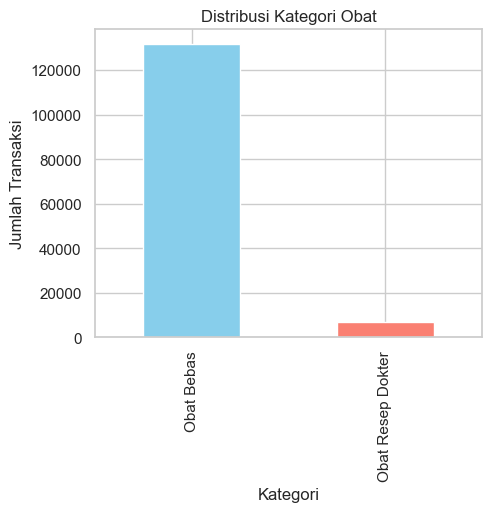

In [12]:

# Distribusi kategori
dist = df_pembelian["kategori"].value_counts(normalize=True) * 100
print(dist)

# Visualisasi
plt.figure(figsize=(5,4))
df_pembelian["kategori"].value_counts().plot(kind="bar", color=["skyblue","salmon"])
plt.title("Distribusi Kategori Obat")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Transaksi")
plt.show()

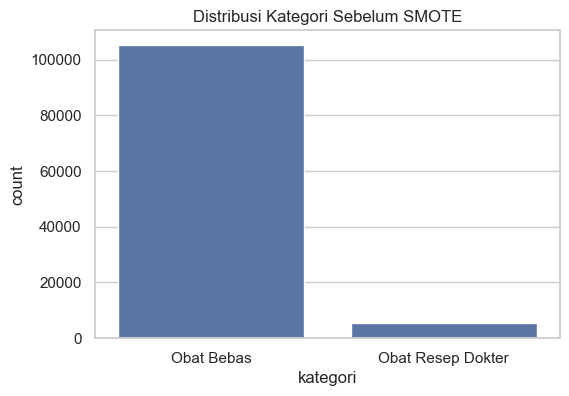


--- Statistik Sebelum SMOTE ---
                   Jumlah  Persentase (%)
kategori                                 
Obat Bebas         105274           95.12
Obat Resep Dokter    5402            4.88
Total sampel sebelum SMOTE: 110676
Rasio kelas tertinggi terhadap terendah: 19.49:1


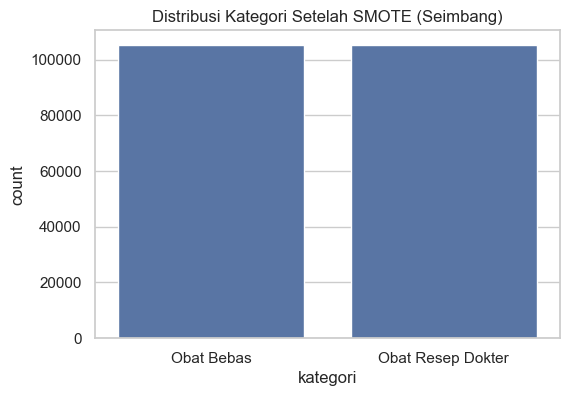


--- Statistik Sesudah SMOTE ---
                   Jumlah  Persentase (%)
kategori                                 
Obat Bebas         105274            50.0
Obat Resep Dokter  105274            50.0
Total sampel sesudah SMOTE: 210548
Rasio kelas tertinggi terhadap terendah: 1.00:1


In [13]:
#Resampling Techcnique dengan SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Pisahkan fitur dan target
X = df_pembelian.drop(columns=["kategori"])
y = df_pembelian["kategori"]

# Label encoding untuk fitur kategorikal
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Split data (stratify untuk menjaga proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Sebelum SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Distribusi Kategori Sebelum SMOTE")
plt.show()
# Sebelum SMOTE
print("\n--- Statistik Sebelum SMOTE ---")
before_counts = y_train.value_counts()
before_total = len(y_train)
before_percent = (before_counts / before_total * 100).round(2)

before_stats = pd.DataFrame({
    'Jumlah': before_counts,
    'Persentase (%)': before_percent
})
print(before_stats)
print(f"Total sampel sebelum SMOTE: {before_total}")
print(f"Rasio kelas tertinggi terhadap terendah: {before_counts.max() / before_counts.min():.2f}:1")

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Setelah SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title("Distribusi Kategori Setelah SMOTE (Seimbang)")
plt.show()

# Sesudah SMOTE
print("\n--- Statistik Sesudah SMOTE ---")
after_counts = y_res.value_counts()
after_total = len(y_res)
after_percent = (after_counts / after_total * 100).round(2)

after_stats = pd.DataFrame({
    'Jumlah': after_counts,
    'Persentase (%)': after_percent
})
print(after_stats)
print(f"Total sampel sesudah SMOTE: {after_total}")
print(f"Rasio kelas tertinggi terhadap terendah: {after_counts.max() / after_counts.min():.2f}:1")

In [14]:
#ALGORITHM-LEVEL METHOD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Model dengan class_weight
model_balanced = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

model_balanced.fit(X_train, y_train)
y_pred_bal = model_balanced.predict(X_test)

print("=== Random Forest dengan class_weight ===")
print(classification_report(y_test, y_pred_bal))


=== Random Forest dengan class_weight ===
                   precision    recall  f1-score   support

       Obat Bebas       0.95      0.99      0.97     26319
Obat Resep Dokter       0.05      0.01      0.02      1351

         accuracy                           0.94     27670
        macro avg       0.50      0.50      0.50     27670
     weighted avg       0.91      0.94      0.92     27670



In [15]:
#HYBRID METHOD
# Oversampling 
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Lalu train model dengan class_weight
model_hybrid = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
model_hybrid.fit(X_res, y_res)
y_pred_hybrid = model_hybrid.predict(X_test)

print("=== Hybrid (SMOTE + class_weight) ===")
print(classification_report(y_test, y_pred_hybrid))


=== Hybrid (SMOTE + class_weight) ===
                   precision    recall  f1-score   support

       Obat Bebas       0.95      0.96      0.95     26319
Obat Resep Dokter       0.05      0.04      0.05      1351

         accuracy                           0.91     27670
        macro avg       0.50      0.50      0.50     27670
     weighted avg       0.91      0.91      0.91     27670



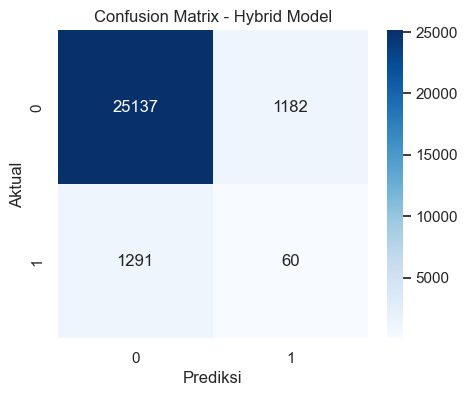

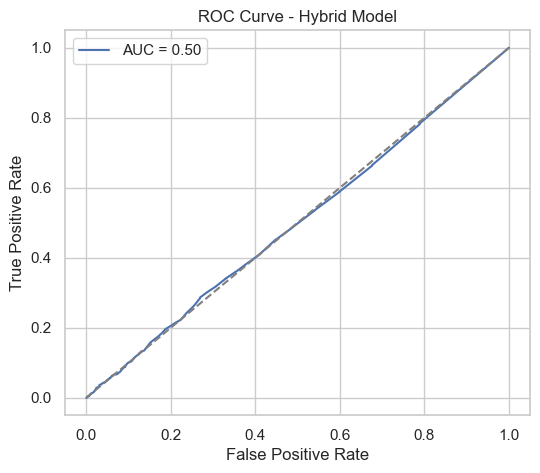

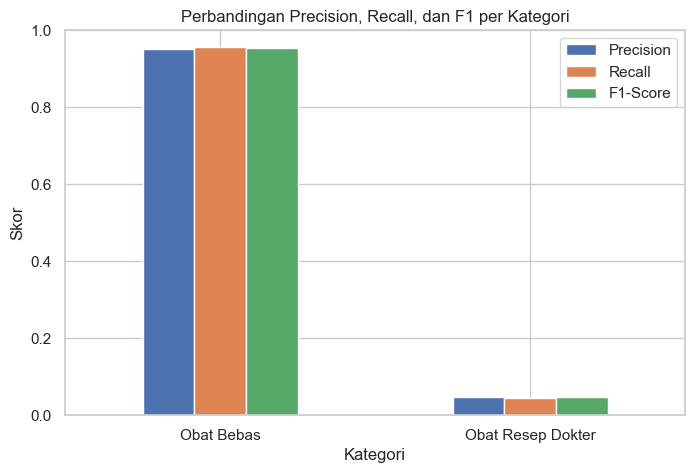

In [16]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_fscore_support
import pandas as pd

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# ROC Curve
if len(set(y_test)) == 2:
    y_prob = model_hybrid.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve((y_test == "Obat Resep Dokter").astype(int), y_prob)
    auc = roc_auc_score((y_test == "Obat Resep Dokter").astype(int), y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Hybrid Model")
    plt.legend()
    plt.show()

# Precision, Recall, F1 bar chart
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_hybrid, labels=model_hybrid.classes_)
metrics_df = pd.DataFrame({
    "Kategori": model_hybrid.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

metrics_df.plot(x="Kategori", kind="bar", figsize=(8,5), ylim=(0,1))
plt.title("Perbandingan Precision, Recall, dan F1 per Kategori")
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.show()

